<h1 style="color:#2E86AB; font-family:Georgia; text-align:center; border-bottom: 3px solid #2E86AB; padding-bottom:10px;">
📄 Extracción de Indicadores Educativos desde PDFs
</h1>

**Autor:** Eddy Luis  
**Fecha:** Mayo 2026  
**Herramientas:** Python · Pandas · pdfplumber

---

## 📌 Descripción
Extraemos las tablas de **promoción, reprobación y abandono** por Regional y Distrito
de los PDFs del MINERD (2021-2024), y las consolidamos en un solo DataFrame
para cruzar con el CSV de centros educativos.

---

## 📋 Contenido de este Notebook

1. ⚙️ Configuración
2. 🔧 Función de Extracción
3. 📥 Extracción de los 4 PDFs (2021-2024)
4. 🏷️ Separar Regional y Distrito
5. 🔄 Transformar a Formato Largo
6. 📊 Tabla Pivoteada de Abandono
7. 📈 Visualización
8. 💾 Guardar Datos Procesados
9. 🔗 Preview del Cruce con Centros Educativos

---

In [12]:
import pandas as pd
import pdfplumber
import re
from pathlib import Path

<h2 style="color:#A23B72; font-family:Georgia;">
⚙️ 1. Configuración
</h2>

Páginas donde se encuentran las tablas de "Porcentaje de promoción, reprobados y abandono por nivel, según regional y distrito" en cada PDF.

In [13]:
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")

PDF_CONFIG = {
    2021: {"file": "indicadores educativos 2021.pdf", "pages": list(range(47, 53)), "lectivo": "2021-2022"},
    2022: {"file": "indicadores educativos 2022.pdf", "pages": list(range(41, 47)), "lectivo": "2022-2023"},
    2023: {"file": "indicadores educativos 2023.pdf", "pages": list(range(46, 52)), "lectivo": "2023-2024"},
    2024: {"file": "indicadores educativos 2024.pdf", "pages": list(range(47, 53)), "lectivo": "2024-2025"},
}

COLUMNAS_INDICADOR = [
    "abandono_inicial", "promovido_inicial", "reprobado_inicial",
    "abandono_primario", "promovido_primario", "reprobado_primario",
    "abandono_secundario", "promovido_secundario", "reprobado_secundario",
]

<h2 style="color:#A23B72; font-family:Georgia;">
🔧 2. Función de Extracción
</h2>

Cada línea de datos tiene el formato: `NOMBRE  1.5  98.5  0.0  2.5  94.1  3.4  5.7  88.1  6.2` (9 valores numéricos: Abandono/Promovido/Reprobado × Inicial/Primario/Secundario).

In [14]:
PATTERN_9 = re.compile(
    r"^(.+?)\s+"
    r"([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+"
    r"([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+"
    r"([\d.]+)\s+([\d.]+)\s+([\d.]+)\s*$"
)

PATTERN_8 = re.compile(
    r"^(.+?)\s+"
    r"([\d.]+)\s+([\d.]+)\s+"
    r"([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+"
    r"([\d.]+)\s+([\d.]+)\s+([\d.]+)\s*$"
)

SKIP_KEYWORDS = ["Anuario", "INICIAL", "Abandono", "Promovido", "Reprobado", "REGIONAL", "Todos los sectores"]


def extraer_indicadores_pdf(filepath, page_indices, año_lectivo):
    """Extrae filas de indicadores de las páginas indicadas de un PDF."""
    rows = []
    with pdfplumber.open(filepath) as pdf:
        for pi in page_indices:
            text = pdf.pages[pi].extract_text()
            if not text:
                continue
            for line in text.split("\n"):
                line = line.strip()
                if not line or any(kw in line for kw in SKIP_KEYWORDS):
                    continue

                match9 = PATTERN_9.match(line)
                if match9:
                    nombre = match9.group(1).strip()
                    vals = [float(match9.group(i)) for i in range(2, 11)]
                    rows.append([nombre, año_lectivo] + vals)
                    continue

                match8 = PATTERN_8.match(line)
                if match8:
                    nombre = match8.group(1).strip()
                    v = [float(match8.group(i)) for i in range(2, 10)]
                    # 2021-2022: sin Reprobado Inicial → insertar 0.0
                    vals = [v[0], v[1], 0.0, v[2], v[3], v[4], v[5], v[6], v[7]]
                    rows.append([nombre, año_lectivo] + vals)

    df = pd.DataFrame(rows, columns=["regional_distrito", "año_lectivo"] + COLUMNAS_INDICADOR)
    return df

<h2 style="color:#A23B72; font-family:Georgia;">
📥 3. Extracción de los 4 PDFs (2021-2024)
</h2>

In [15]:
dfs = []
for year, cfg in PDF_CONFIG.items():
    filepath = RAW_DIR / cfg["file"]
    df_year = extraer_indicadores_pdf(filepath, cfg["pages"], cfg["lectivo"])
    print(f"{cfg['lectivo']}: {len(df_year)} filas extraídas")
    dfs.append(df_year)

df_indicadores = pd.concat(dfs, ignore_index=True)
print(f"\nTotal consolidado: {df_indicadores.shape}")
df_indicadores.head(10)

2021-2022: 141 filas extraídas
2022-2023: 141 filas extraídas
2023-2024: 141 filas extraídas
2024-2025: 141 filas extraídas

Total consolidado: (564, 11)


,regional_distrito,año_lectivo,abandono_inicial,promovido_inicial,reprobado_inicial,abandono_primario,promovido_primario,reprobado_primario,abandono_secundario,promovido_secundario,reprobado_secundario
0,TOTAL,2021-2022,1.6,98.4,0.0,2.3,91.7,6.0,5.2,88.6,6.1
1,01 - BARAHONA,2021-2022,1.6,98.4,0.0,5.0,84.9,10.0,8.9,83.7,7.3
2,0101 - PEDERNALES,2021-2022,1.4,98.6,0.0,6.4,84.7,8.9,12.2,80.6,7.3
3,0102 - ENRIQUILLO,2021-2022,2.8,97.2,0.0,10.4,76.0,13.6,12.0,82.3,5.8
4,0103 - BARAHONA,2021-2022,1.7,98.3,0.0,3.7,85.6,10.7,7.5,86.0,6.4
5,0104 - CABRAL,2021-2022,2.3,97.7,0.0,3.8,90.2,6.1,6.6,83.1,10.3
6,0105 - VICENTE NOBLE,2021-2022,0.1,99.9,0.0,4.0,88.1,7.9,11.5,78.8,9.7
7,02 - SAN JUAN DE LA MAGUANA,2021-2022,1.7,98.3,0.0,4.4,87.3,8.3,7.5,82.7,9.8
8,0201 - COMENDADOR,2021-2022,0.7,99.3,0.0,8.3,83.1,8.6,10.8,80.3,8.9
9,0202 - PEDRO SANTANA,2021-2022,1.6,98.4,0.0,7.8,82.1,10.0,9.4,83.7,6.9


<h2 style="color:#A23B72; font-family:Georgia;">
🏷️ 4. Separar Regional y Distrito
</h2>

- **Regional**: código de 2 dígitos (ej. `01 - BARAHONA`)
- **Distrito**: código de 4 dígitos (ej. `0101 - PEDERNALES`)
- `TOTAL`: fila resumen nacional

In [16]:
def clasificar_nivel(nombre):
    if nombre == "TOTAL":
        return "total", None, None
    code = nombre.split(" - ")[0].strip()
    if len(code) == 2 and code.isdigit():
        return "regional", nombre, None
    elif len(code) == 4 and code.isdigit():
        regional_code = code[:2]
        return "distrito", None, nombre
    return "otro", None, None

df_indicadores[["tipo", "regional", "distrito"]] = df_indicadores["regional_distrito"].apply(
    lambda x: pd.Series(clasificar_nivel(x))
)

# Propagar la regional hacia abajo para asociar cada distrito con su regional
current_regional = None
regionales = []
for _, row in df_indicadores.iterrows():
    if row["tipo"] == "regional":
        current_regional = row["regional_distrito"]
    elif row["tipo"] == "total":
        current_regional = None
    regionales.append(current_regional)

df_indicadores["regional"] = regionales

print(df_indicadores["tipo"].value_counts())
df_indicadores.head(15)

tipo
distrito    488
regional     72
total         4
Name: count, dtype: int64


,regional_distrito,año_lectivo,abandono_inicial,promovido_inicial,reprobado_inicial,abandono_primario,promovido_primario,reprobado_primario,abandono_secundario,promovido_secundario,reprobado_secundario,tipo,regional,distrito
0,TOTAL,2021-2022,1.6,98.4,0.0,2.3,91.7,6.0,5.2,88.6,6.1,total,NaN,NaN
1,01 - BARAHONA,2021-2022,1.6,98.4,0.0,5.0,84.9,10.0,8.9,83.7,7.3,regional,01 - BARAHONA,NaN
2,0101 - PEDERNALES,2021-2022,1.4,98.6,0.0,6.4,84.7,8.9,12.2,80.6,7.3,distrito,01 - BARAHONA,0101 - PEDERNALES
3,0102 - ENRIQUILLO,2021-2022,2.8,97.2,0.0,10.4,76.0,13.6,12.0,82.3,5.8,distrito,01 - BARAHONA,0102 - ENRIQUILLO
4,0103 - BARAHONA,2021-2022,1.7,98.3,0.0,3.7,85.6,10.7,7.5,86.0,6.4,distrito,01 - BARAHONA,0103 - BARAHONA
5,0104 - CABRAL,2021-2022,2.3,97.7,0.0,3.8,90.2,6.1,6.6,83.1,10.3,distrito,01 - BARAHONA,0104 - CABRAL
6,0105 - VICENTE NOBLE,2021-2022,0.1,99.9,0.0,4.0,88.1,7.9,11.5,78.8,9.7,distrito,01 - BARAHONA,0105 - VICENTE NOBLE
7,02 - SAN JUAN DE LA MAGUANA,2021-2022,1.7,98.3,0.0,4.4,87.3,8.3,7.5,82.7,9.8,regional,02 - SAN JUAN DE LA MAGUANA,NaN
8,0201 - COMENDADOR,2021-2022,0.7,99.3,0.0,8.3,83.1,8.6,10.8,80.3,8.9,distrito,02 - SAN JUAN DE LA MAGUANA,0201 - COMENDADOR
9,0202 - PEDRO SANTANA,2021-2022,1.6,98.4,0.0,7.8,82.1,10.0,9.4,83.7,6.9,distrito,02 - SAN JUAN DE LA MAGUANA,0202 - PEDRO SANTANA


<h2 style="color:#A23B72; font-family:Georgia;">
🔄 5. Transformar a Formato Largo (melt)
</h2>

Convertimos las 9 columnas de indicadores a formato largo con columnas: `nivel`, `indicador`, `valor`.

In [17]:
df_long = df_indicadores.melt(
    id_vars=["regional_distrito", "año_lectivo", "tipo", "regional", "distrito"],
    value_vars=COLUMNAS_INDICADOR,
    var_name="indicador_nivel",
    value_name="valor",
)

df_long["indicador"] = df_long["indicador_nivel"].str.split("_").str[0]
df_long["nivel"] = df_long["indicador_nivel"].str.split("_").str[1].str.upper()
df_long.drop(columns=["indicador_nivel"], inplace=True)

print(f"Formato largo: {df_long.shape}")
print(f"\nIndicadores: {df_long['indicador'].unique()}")
print(f"Niveles: {df_long['nivel'].unique()}")
df_long.head(10)

Formato largo: (5076, 8)

Indicadores: ['abandono' 'promovido' 'reprobado']
Niveles: ['INICIAL' 'PRIMARIO' 'SECUNDARIO']


,regional_distrito,año_lectivo,tipo,regional,distrito,valor,indicador,nivel
0,TOTAL,2021-2022,total,NaN,NaN,1.6,abandono,INICIAL
1,01 - BARAHONA,2021-2022,regional,01 - BARAHONA,NaN,1.6,abandono,INICIAL
2,0101 - PEDERNALES,2021-2022,distrito,01 - BARAHONA,0101 - PEDERNALES,1.4,abandono,INICIAL
3,0102 - ENRIQUILLO,2021-2022,distrito,01 - BARAHONA,0102 - ENRIQUILLO,2.8,abandono,INICIAL
4,0103 - BARAHONA,2021-2022,distrito,01 - BARAHONA,0103 - BARAHONA,1.7,abandono,INICIAL
5,0104 - CABRAL,2021-2022,distrito,01 - BARAHONA,0104 - CABRAL,2.3,abandono,INICIAL
6,0105 - VICENTE NOBLE,2021-2022,distrito,01 - BARAHONA,0105 - VICENTE NOBLE,0.1,abandono,INICIAL
7,02 - SAN JUAN DE LA MAGUANA,2021-2022,regional,02 - SAN JUAN DE LA MAGUANA,NaN,1.7,abandono,INICIAL
8,0201 - COMENDADOR,2021-2022,distrito,02 - SAN JUAN DE LA MAGUANA,0201 - COMENDADOR,0.7,abandono,INICIAL
9,0202 - PEDRO SANTANA,2021-2022,distrito,02 - SAN JUAN DE LA MAGUANA,0202 - PEDRO SANTANA,1.6,abandono,INICIAL


<h2 style="color:#A23B72; font-family:Georgia;">
📊 6. Tabla Pivoteada de Abandono por Regional
</h2>

Vista rápida: tasa de abandono del nivel Secundario por Regional a lo largo de los años.

In [18]:
abandono_sec = df_long[
    (df_long["tipo"] == "regional") &
    (df_long["indicador"] == "abandono") &
    (df_long["nivel"] == "SECUNDARIO")
]

pivot_abandono = abandono_sec.pivot_table(
    index="regional", columns="año_lectivo", values="valor"
).round(1)

pivot_abandono

año_lectivo,2021-2022,2022-2023,2023-2024,2024-2025
regional,,,,
01 - BARAHONA,8.9,6.0,6.1,6.0
02 - SAN JUAN DE LA MAGUANA,7.5,7.8,7.2,8.2
03 - AZUA,6.9,6.2,5.7,7.0
04 - SAN CRISTOBAL,4.7,3.8,3.4,4.7
05 - SAN PEDRO DE MACORIS,5.6,5.1,4.6,6.3
06 - LA VEGA,5.3,4.3,4.0,4.5
07 - SAN FRANCISCO DE MACORIS,8.2,5.8,6.3,8.1
08 - SANTIAGO,5.2,4.5,4.2,6.0
09 - MAO,6.6,5.2,4.9,7.0


<h2 style="color:#A23B72; font-family:Georgia;">
📈 7. Visualización: Evolución del Abandono por Regional
</h2>

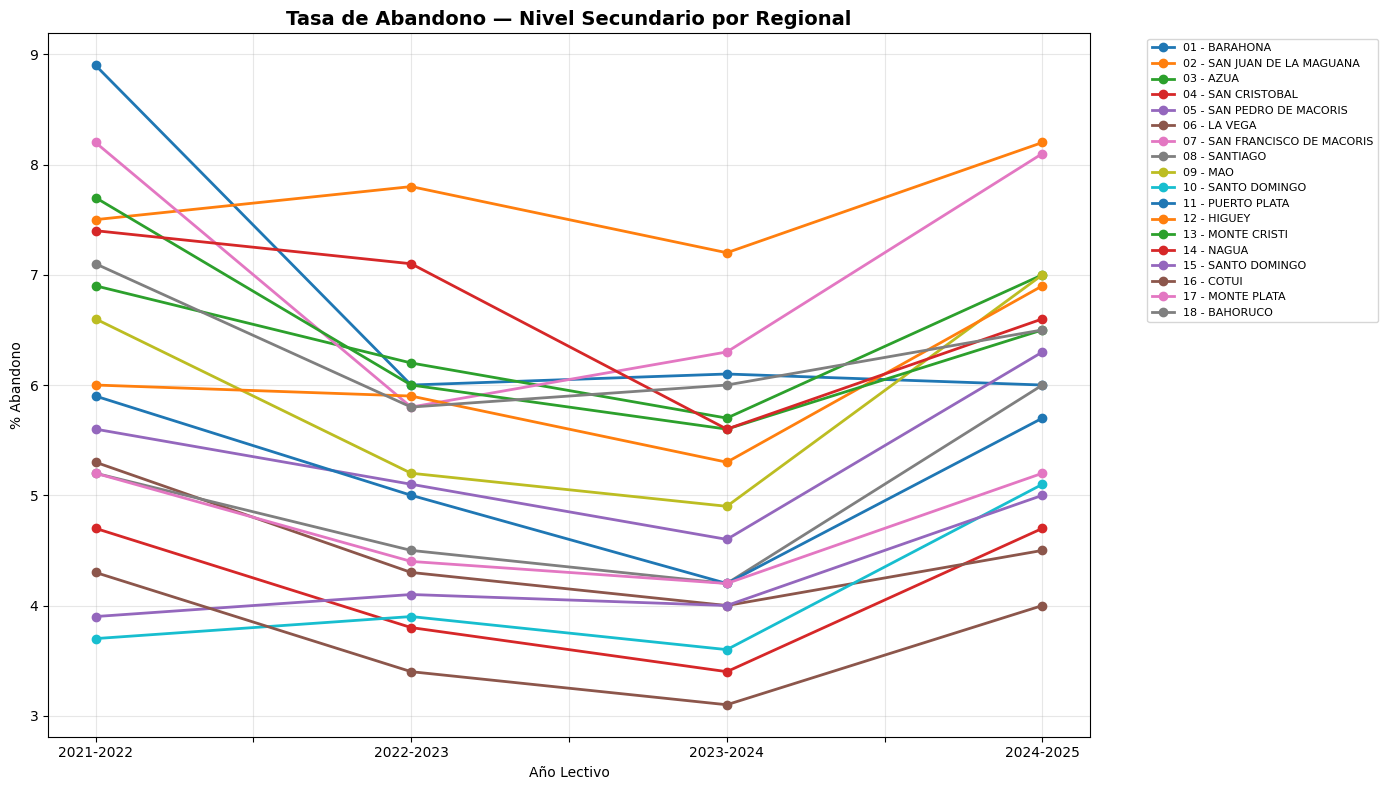

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 8))
pivot_abandono.T.plot(ax=ax, marker="o", linewidth=2)
ax.set_title("Tasa de Abandono — Nivel Secundario por Regional", fontsize=14, fontweight="bold")
ax.set_ylabel("% Abandono")
ax.set_xlabel("Año Lectivo")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<h2 style="color:#A23B72; font-family:Georgia;">
💾 8. Guardar Datos Procesados
</h2>

In [20]:
# Formato ancho
df_indicadores.to_csv(PROCESSED_DIR / "indicadores_educativos_ancho.csv", index=False)

# Formato largo
df_long.to_csv(PROCESSED_DIR / "indicadores_educativos_largo.csv", index=False)

print(f"Guardado formato ancho: {df_indicadores.shape}")
print(f"Guardado formato largo: {df_long.shape}")

Guardado formato ancho: (564, 14)
Guardado formato largo: (5076, 8)


<h2 style="color:#A23B72; font-family:Georgia;">
🔗 9. Preview del Cruce con Centros Educativos
</h2>

Verificamos que las columnas `regional` coincidan entre el CSV de centros y los indicadores extraídos.

In [21]:
df_centros = pd.read_csv(PROCESSED_DIR / "centros_educativos_limpios.csv")

regionales_centros = set(df_centros["regional"].unique())
regionales_indicadores = set(
    df_indicadores[df_indicadores["tipo"] == "regional"]["regional_distrito"].unique()
)

print("Regionales en centros educativos:")
print(sorted(regionales_centros))
print(f"\nRegionales en indicadores:")
print(sorted(regionales_indicadores))
print(f"\nCoincidencias: {len(regionales_centros & regionales_indicadores)} / {len(regionales_centros)}")

diferencias = regionales_centros.symmetric_difference(regionales_indicadores)
if diferencias:
    print(f"\nDiferencias: {diferencias}")

Regionales en centros educativos:
['01 - BARAHONA', '02 - SAN JUAN DE LA MAGUANA', '03 - AZUA', '04 - SAN CRISTOBAL', '05 - SAN PEDRO DE MACORIS', '06 - LA VEGA', '07 - SAN FRANCISCO DE MACORIS', '08 - SANTIAGO', '09 - MAO', '10 - SANTO DOMINGO', '11 - PUERTO PLATA', '12 - HIGUEY', '13 - MONTE CRISTI', '14 - NAGUA', '15 - SANTO DOMINGO', '16 - COTUI', '17 - MONTE PLATA', '18 - BAHORUCO']

Regionales en indicadores:
['01 - BARAHONA', '02 - SAN JUAN DE LA MAGUANA', '03 - AZUA', '04 - SAN CRISTOBAL', '05 - SAN PEDRO DE MACORIS', '06 - LA VEGA', '07 - SAN FRANCISCO DE MACORIS', '08 - SANTIAGO', '09 - MAO', '10 - SANTO DOMINGO', '11 - PUERTO PLATA', '12 - HIGUEY', '13 - MONTE CRISTI', '14 - NAGUA', '15 - SANTO DOMINGO', '16 - COTUI', '17 - MONTE PLATA', '18 - BAHORUCO']

Coincidencias: 18 / 18


In [22]:
# Preview: merge de abandono secundario (nivel regional) con centros
indicadores_regional = df_indicadores[df_indicadores["tipo"] == "regional"][
    ["regional_distrito", "año_lectivo", "abandono_inicial", "abandono_primario", "abandono_secundario"]
].rename(columns={"regional_distrito": "regional"})

preview_merge = df_centros.merge(indicadores_regional, on="regional", how="left")
print(f"Centros con indicadores: {preview_merge['abandono_secundario'].notna().sum()} / {len(preview_merge)}")
preview_merge[["centros", "regional", "nivel", "año_lectivo", "abandono_secundario"]].head(10)

Centros con indicadores: 72456 / 72456


,centros,regional,nivel,año_lectivo,abandono_secundario
0,02334 - HERNANDO GORJON,01 - BARAHONA,INICIAL - PRIMARIO - SECUNDARIO,2021-2022,8.9
1,02334 - HERNANDO GORJON,01 - BARAHONA,INICIAL - PRIMARIO - SECUNDARIO,2022-2023,6.0
2,02334 - HERNANDO GORJON,01 - BARAHONA,INICIAL - PRIMARIO - SECUNDARIO,2023-2024,6.1
3,02334 - HERNANDO GORJON,01 - BARAHONA,INICIAL - PRIMARIO - SECUNDARIO,2024-2025,6.0
4,02335 - BIENVENIDO MORILLO,01 - BARAHONA,INICIAL - PRIMARIO,2021-2022,8.9
5,02335 - BIENVENIDO MORILLO,01 - BARAHONA,INICIAL - PRIMARIO,2022-2023,6.0
6,02335 - BIENVENIDO MORILLO,01 - BARAHONA,INICIAL - PRIMARIO,2023-2024,6.1
7,02335 - BIENVENIDO MORILLO,01 - BARAHONA,INICIAL - PRIMARIO,2024-2025,6.0
8,02336 - EZEQUIEL HERNANDEZ MENDEZ,01 - BARAHONA,INICIAL - PRIMARIO - SECUNDARIO,2021-2022,8.9
9,02336 - EZEQUIEL HERNANDEZ MENDEZ,01 - BARAHONA,INICIAL - PRIMARIO - SECUNDARIO,2022-2023,6.0
